# Sesión 02 — Modelos de Clasificación
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Dataset:** AI and Social Media Impact — Student Health and Grades (Kaggle, 16 000 estudiantes; se trabaja con una muestra de 6000, clasificación binaria)

---

## 1. Configuración del entorno

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate, GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **AI and Social Media Impact** contiene 16 000 estudiantes (13–25 años) con sus hábitos diarios (horas en redes sociales, uso de herramientas de IA, sueño, actividad física) y dos puntajes de salud: `Mental_Health_Score` y `Physical_Health_Score`. Se trabaja con una **muestra estratificada de 6000 estudiantes** para que SVM y KNN corran en un tiempo razonable.

El dataset no trae una clase lista, así que se construye el target binario a partir de `Mental_Health_Score`: **en riesgo (1)** si el puntaje es **menor a 70**, o **sin riesgo (0)** en caso contrario. Esto genera un problema con desbalance moderado (~35% en riesgo), similar al del notebook de clase.

Se descartan `Student_ID` (identificador) y `Education_Level` (queda determinado por `Age`).

In [5]:

NOMBRE_CSV = 'AI_SocialMedia_Student_Dataset.csv'

try:
    import kagglehub, glob, os
    carpeta = kagglehub.dataset_download('srisyra02/ai-and-social-media-impact-student-health-and-grades')
    ruta_csv = glob.glob(os.path.join(carpeta, '**', NOMBRE_CSV), recursive=True)[0]
    print(f'Dataset descargado en: {carpeta}')
except Exception as e:
    ruta_csv = NOMBRE_CSV
    print(f'No se pudo descargar desde Kaggle: {e}')
    print('Usando el CSV local ...')

df = pd.read_csv(ruta_csv)

# Muestra estratificada de 6000 estudiantes (según el target)
df['target'] = (df['Mental_Health_Score'] < 70).astype(int)
df = (df.groupby('target', group_keys=False)
        .sample(frac=6000 / len(df), random_state=42)
        .reset_index(drop=True))
df['estado'] = df['target'].map({0: 'sin riesgo', 1: 'en riesgo'})

features_base = ['Age', 'Gender', 'Daily_Social_Media_Hours', 'Daily_AI_Tool_Usage_Hours',
                 'Sleep_Hours', 'Physical_Activity_Hours', 'Physical_Health_Score']

print(f'Dataset: {df.shape[0]} estudiantes, {len(features_base)} features')
print(f'\nDistribución de clases:')
print(df['estado'].value_counts())
print(f'\nProporción: {df["target"].mean():.1%} en riesgo, {1-df["target"].mean():.1%} sin riesgo')

Dataset descargado en: C:\Users\ANTONY\.cache\kagglehub\datasets\srisyra02\ai-and-social-media-impact-student-health-and-grades\versions\1
Dataset: 6000 estudiantes, 7 features

Distribución de clases:
estado
sin riesgo    3873
en riesgo     2127
Name: count, dtype: int64

Proporción: 35.4% en riesgo, 64.5% sin riesgo


In [6]:
df[features_base + ['Mental_Health_Score']].describe().round(3)

,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Physical_Health_Score,Mental_Health_Score
count,6000.000,6000.000,6000.000,6000.000,6000.000,6000.000,6000.000
mean,19.051,4.573,2.586,6.544,1.261,88.103,72.512
std,3.769,2.403,1.681,1.259,1.037,9.684,9.230
min,13.000,0.000,0.000,2.390,0.000,48.400,32.560
25%,16.000,2.850,1.300,5.700,0.320,81.800,66.920
50%,19.000,4.540,2.530,6.540,1.150,89.720,73.690
75%,22.000,6.190,3.750,7.390,1.970,97.210,79.490
max,25.000,12.820,9.500,11.150,5.000,99.980,91.210


---
## 3. Análisis exploratorio orientado a clasificación

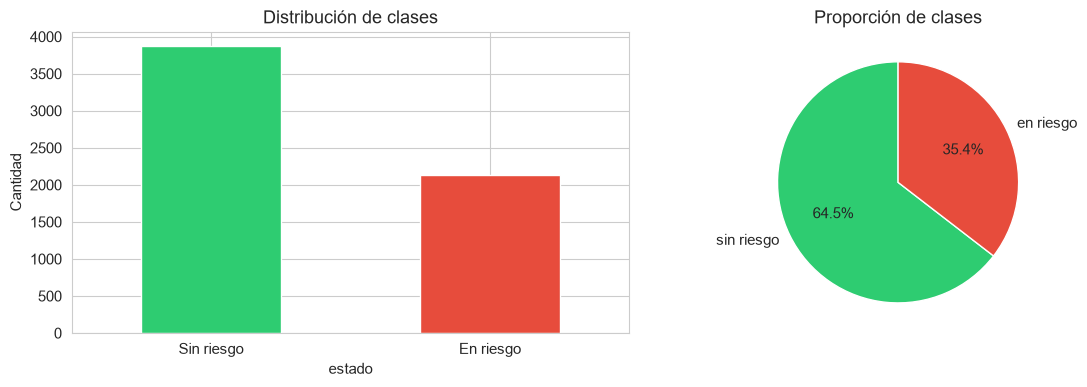

In [7]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
colors = ['#2ecc71', '#e74c3c']
df['estado'].value_counts().sort_index(ascending=False).plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Sin riesgo', 'En riesgo'], rotation=0)

# Pie chart
df['estado'].value_counts().sort_index(ascending=False).plot(kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

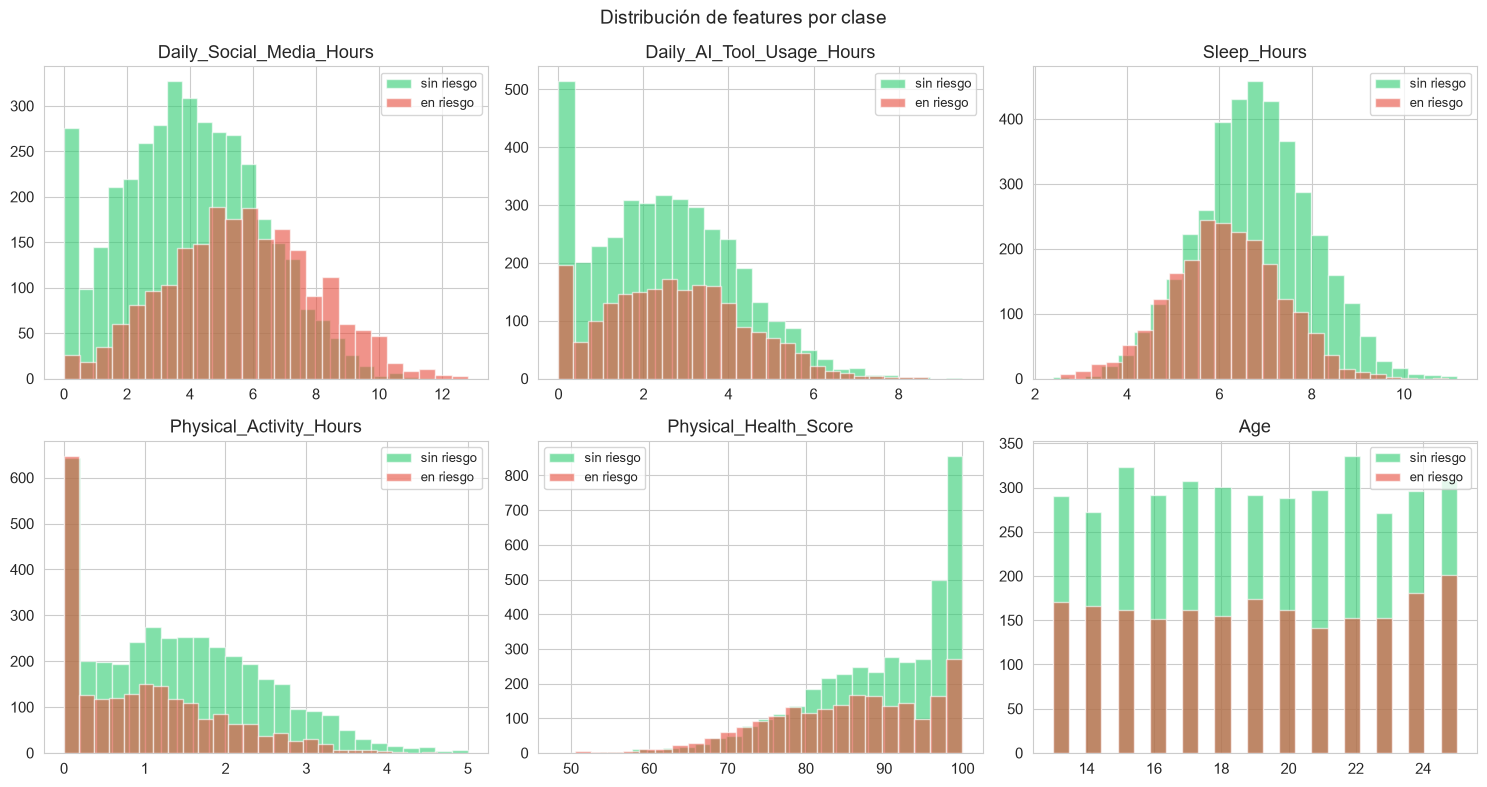

In [8]:
# 3.2  Distribución de features clave por clase
key_features = ['Daily_Social_Media_Hours', 'Daily_AI_Tool_Usage_Hours', 'Sleep_Hours',
                'Physical_Activity_Hours', 'Physical_Health_Score', 'Age']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors):
        subset = df[df['target'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='sin riesgo' if label == 0 else 'en riesgo')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

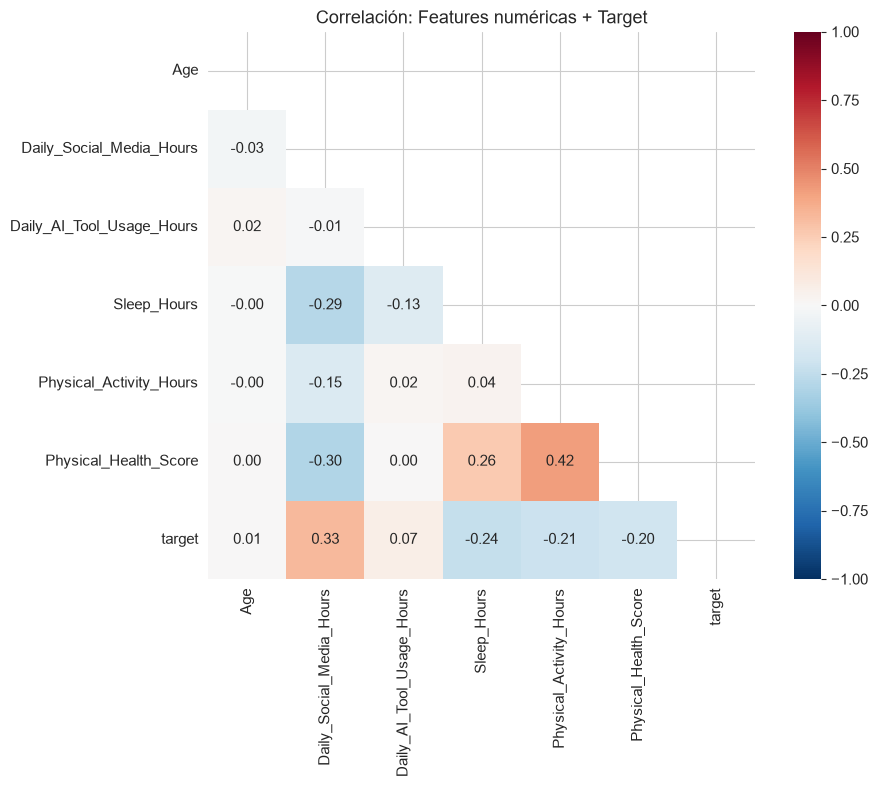

In [9]:
# 3.3  Matriz de correlación (features numéricas)
num_features = [c for c in features_base if c != 'Gender']
plt.figure(figsize=(10, 8))
corr = df[num_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Features numéricas + Target')
plt.tight_layout()
plt.show()

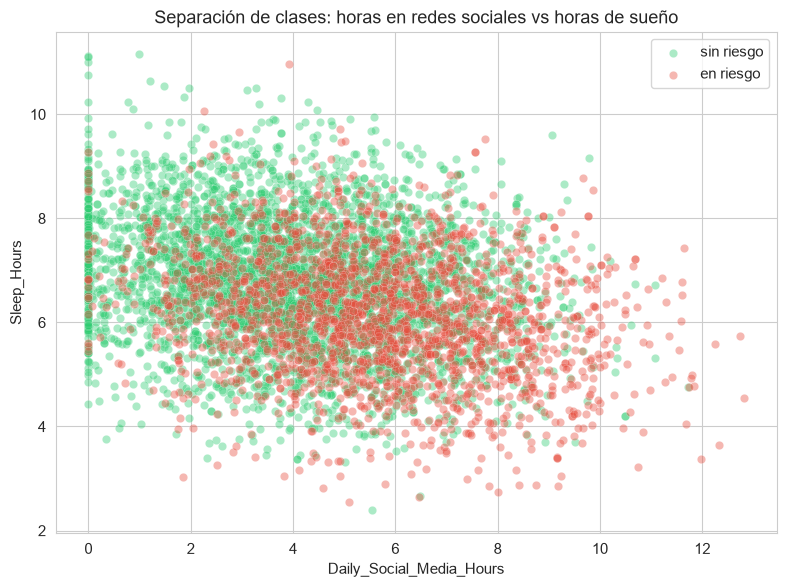

In [10]:
# 3.4  Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors, ['sin riesgo', 'en riesgo']):
    mask = df['target'] == label
    ax.scatter(df.loc[mask, 'Daily_Social_Media_Hours'], df.loc[mask, 'Sleep_Hours'],
              alpha=0.4, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('Daily_Social_Media_Hours')
ax.set_ylabel('Sleep_Hours')
ax.set_title('Separación de clases: horas en redes sociales vs horas de sueño')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [11]:
# La variable categórica Gender se convierte en columnas 0/1 (one-hot)
X = pd.get_dummies(df[features_base], columns=['Gender'], drop_first=True, dtype=float)
y = df['target'].copy()
features = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features: {features}')
print(f'\nEntrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} en riesgo')
print(f'Proporción en test:  {y_test.mean():.1%} en riesgo')

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Features: ['Age', 'Daily_Social_Media_Hours', 'Daily_AI_Tool_Usage_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Physical_Health_Score', 'Gender_Male', 'Gender_Non-binary']

Entrenamiento: 4800 muestras
Test:          1200 muestras

Proporción en train: 35.5% en riesgo
Proporción en test:  35.4% en riesgo


### Funciones auxiliares para evaluación de clasificadores

In [12]:
def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador: métricas, matriz de confusión y reporte."""
    y_pred = model.predict(X_te)
    
    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }
    
    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')
    
    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Sin riesgo', 'En riesgo'],
                yticklabels=['Sin riesgo', 'En riesgo'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    
    # Desglose FP y FN
    tn, fp, fn, tp = cm.ravel()
    labels = ['TN\n(sin riesgo\ncorrecto)', 'FP\n(sin riesgo→\nen riesgo)',
              'FN\n(en riesgo→\nsin riesgo)', 'TP\n(en riesgo\ncorrecto)']
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')
    
    plt.tight_layout()
    plt.show()
    
    print(f'\n  FN (en riesgo no detectado): {fn}')
    print(f'  FP (sin riesgo marcado como en riesgo): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred,
          target_names=['sin riesgo', 'en riesgo']))
    
    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Genera la curva ROC de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        print(f'{model_name}: no soporta probabilidades')
        return None
    
    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, linewidth=2,
            label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()
    
    return roc_auc

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada binaria) con regularización L2 por defecto.

In [13]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1"].mean():.4f} ± {cv_lr["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall"].mean():.4f} ± {cv_lr["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.7025 ± 0.0113
  F1-Score:  0.4911 ± 0.0227
  Recall:    0.4054 ± 0.0285


=== Regresión Logística ===
  Accuracy: 0.7150
  Precision: 0.6456
  Recall: 0.4329
  F1-Score: 0.5183


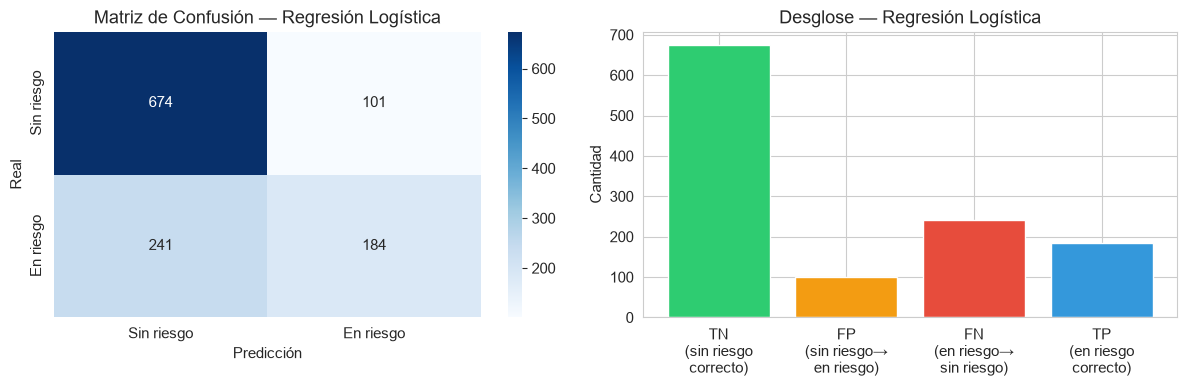


  FN (en riesgo no detectado): 241
  FP (sin riesgo marcado como en riesgo): 101

Reporte completo:
              precision    recall  f1-score   support

  sin riesgo       0.74      0.87      0.80       775
   en riesgo       0.65      0.43      0.52       425

    accuracy                           0.71      1200
   macro avg       0.69      0.65      0.66      1200
weighted avg       0.70      0.71      0.70      1200



In [14]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test,
                             'Regresión Logística')

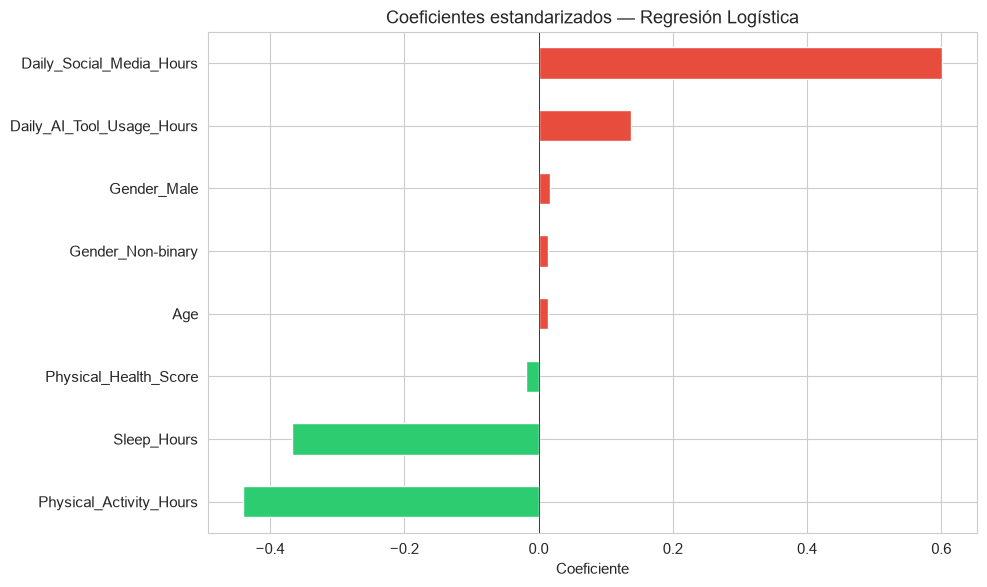

Interpretación:
  → Features que más indican EN RIESGO: ['Gender_Male', 'Daily_AI_Tool_Usage_Hours', 'Daily_Social_Media_Hours']
  → Features que más indican SIN RIESGO: ['Physical_Activity_Hours', 'Sleep_Hours', 'Physical_Health_Score']


In [15]:
# 5.3  Coeficientes estandarizados
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#2ecc71' if c < 0 else '#e74c3c' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican EN RIESGO: {coefs.tail(3).index.tolist()}')
print(f'  → Features que más indican SIN RIESGO: {coefs.head(3).index.tolist()}')

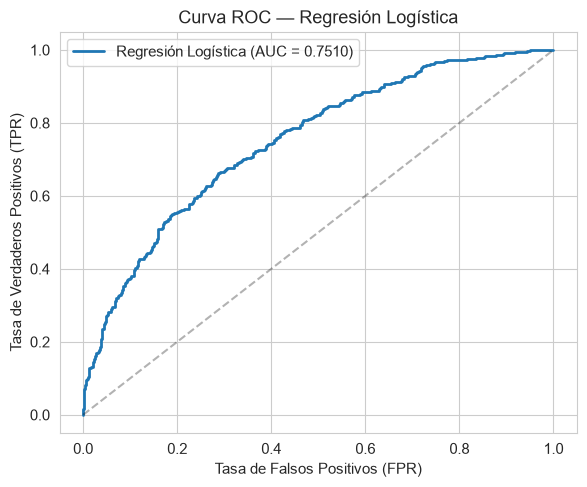

AUC: 0.7510


In [16]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes.

In [17]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1', 'recall'],
                            return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print(f'\n⚠ Train accuracy ~1.0 indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.6233 ± 0.0075
  Test F1-Score:  0.4746 ± 0.0185

⚠ Train accuracy ~1.0 indica sobreajuste


In [18]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1"].mean():.4f} ± {cv_dt["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall"].mean():.4f} ± {cv_dt["test_recall"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.7137
  Test Accuracy:  0.6779 ± 0.0201
  Test F1-Score:  0.4304 ± 0.0309
  Test Recall:    0.3479 ± 0.0643


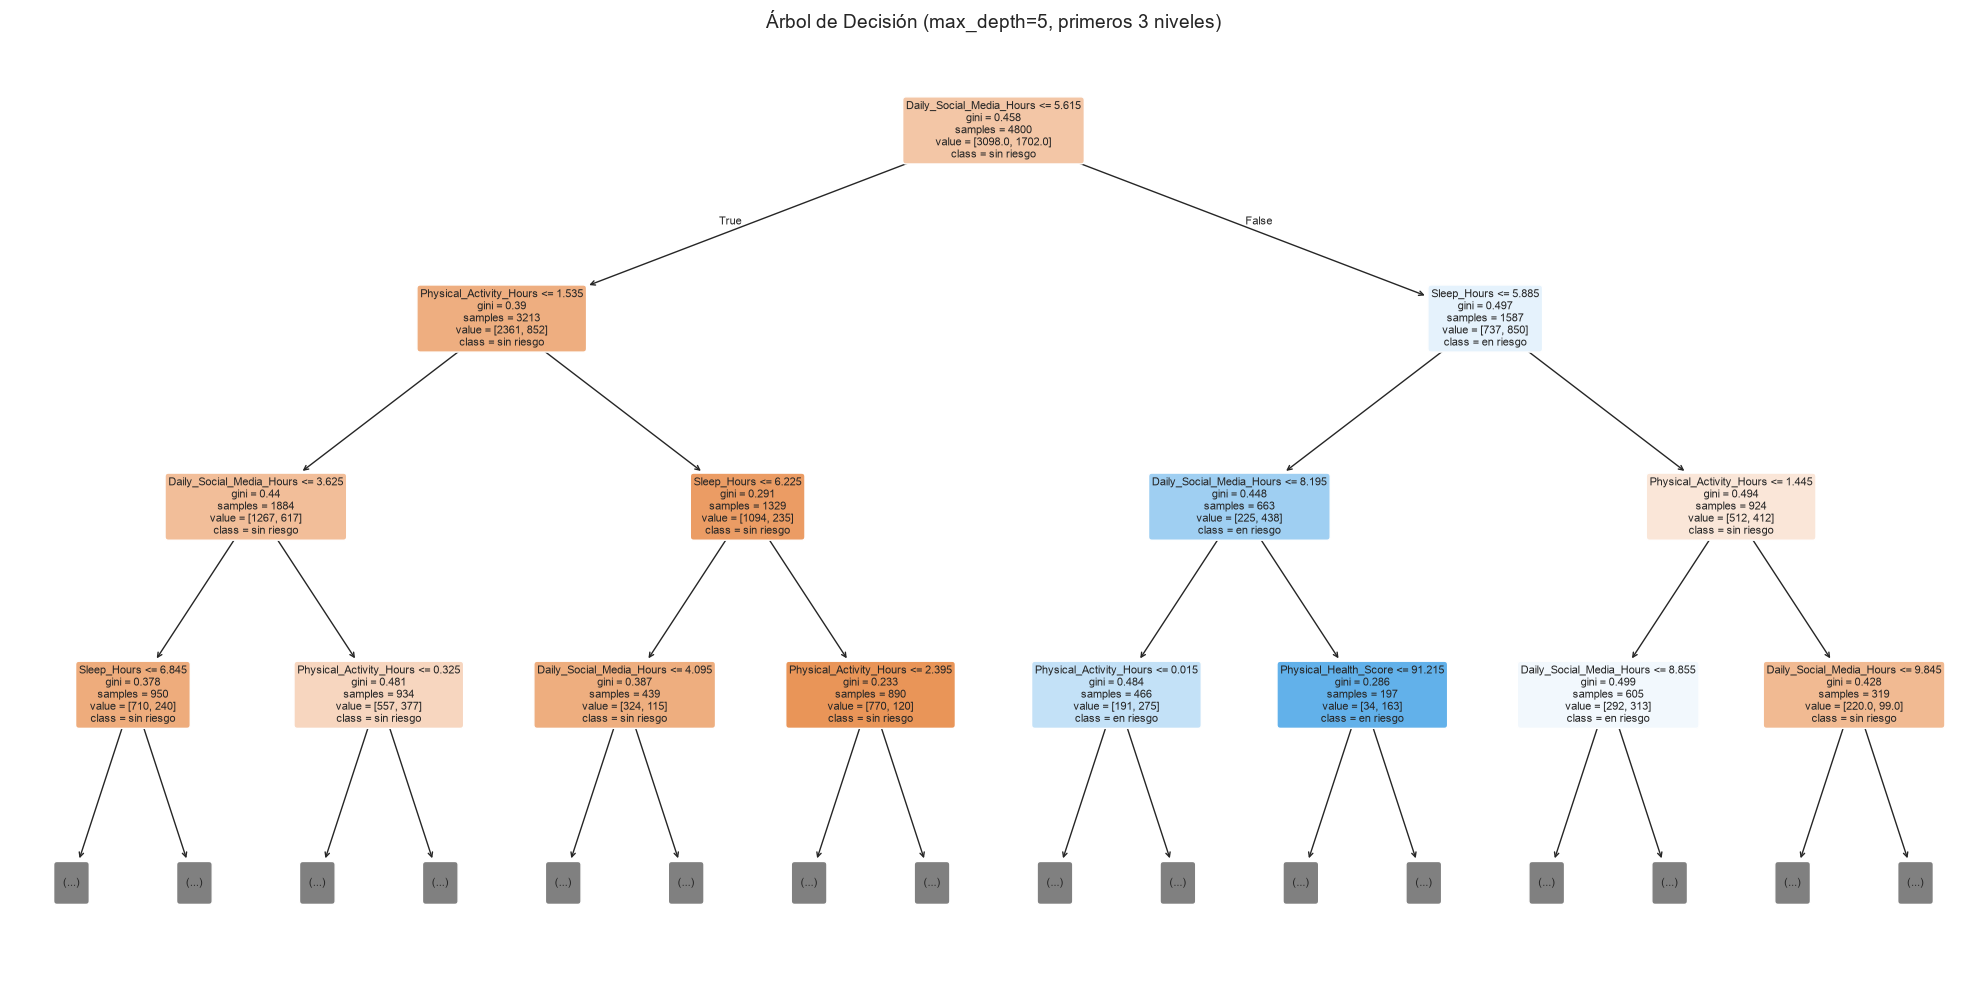

In [19]:
# 6.3  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=features,
          class_names=['sin riesgo', 'en riesgo'],
          filled=True, rounded=True, fontsize=8, ax=ax,
          max_depth=3)  # Mostrar solo 3 niveles para legibilidad
ax.set_title('Árbol de Decisión (max_depth=5, primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.7042
  Precision: 0.6241
  Recall: 0.4141
  F1-Score: 0.4979


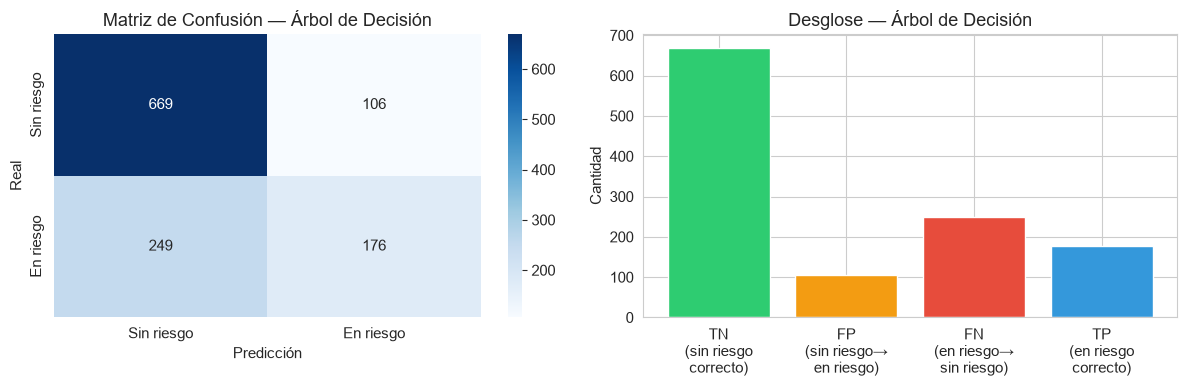


  FN (en riesgo no detectado): 249
  FP (sin riesgo marcado como en riesgo): 106

Reporte completo:
              precision    recall  f1-score   support

  sin riesgo       0.73      0.86      0.79       775
   en riesgo       0.62      0.41      0.50       425

    accuracy                           0.70      1200
   macro avg       0.68      0.64      0.64      1200
weighted avg       0.69      0.70      0.69      1200



In [20]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test,
                             'Árbol de Decisión')

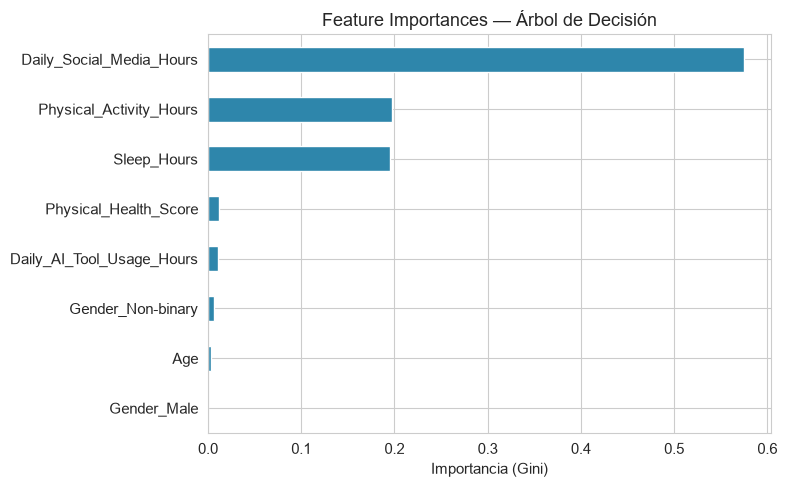

In [21]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

# Todas las features (solo hay 8)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

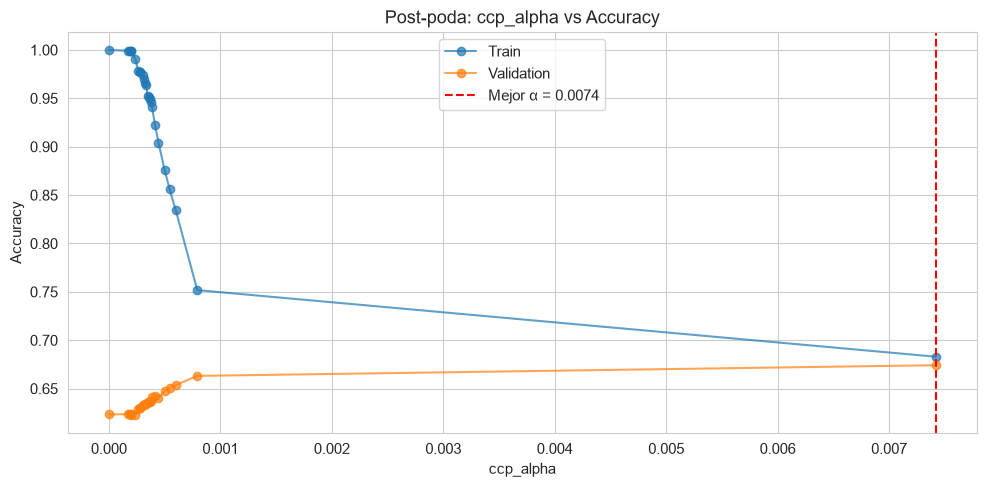

Mejor ccp_alpha: 0.007417


In [22]:
# 6.6  Post-poda con ccp_alpha
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]  # excluir el último (árbol trivial)

# Con muchos datos hay cientos de alphas: se toma una muestra de 25 valores
alphas = alphas[np.linspace(0, len(alphas) - 1, 25).astype(int)]

train_scores, test_scores = [], []
for alpha in alphas:
    dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_temp = cross_validate(dt_temp, X_train, y_train, cv=skf,
                             scoring='accuracy', return_train_score=True)
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)
best_idx = np.argmax(test_scores)
ax.axvline(x=alphas[best_idx], color='red', linestyle='--',
           label=f'Mejor α = {alphas[best_idx]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖ que separa las clases. Con margen suave, permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El kernel trick transforma el espacio para manejar no linealidad.

In [23]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1"].mean():.4f} ± {cv_svm["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall"].mean():.4f} ± {cv_svm["test_recall"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.6994 ± 0.0081
  F1-Score:  0.4202 ± 0.0164
  Recall:    0.3073 ± 0.0141


=== SVM (RBF) ===
  Accuracy: 0.7000
  Precision: 0.6757
  Recall: 0.2941
  F1-Score: 0.4098


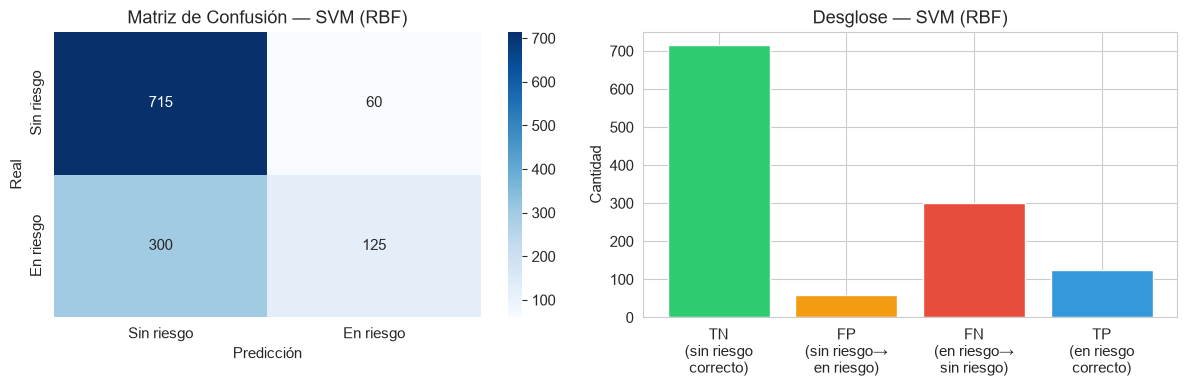


  FN (en riesgo no detectado): 300
  FP (sin riesgo marcado como en riesgo): 60

Reporte completo:
              precision    recall  f1-score   support

  sin riesgo       0.70      0.92      0.80       775
   en riesgo       0.68      0.29      0.41       425

    accuracy                           0.70      1200
   macro avg       0.69      0.61      0.60      1200
weighted avg       0.69      0.70      0.66      1200



In [24]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.7050
  Kernel rbf     : Accuracy = 0.6994
  Kernel poly    : Accuracy = 0.6888


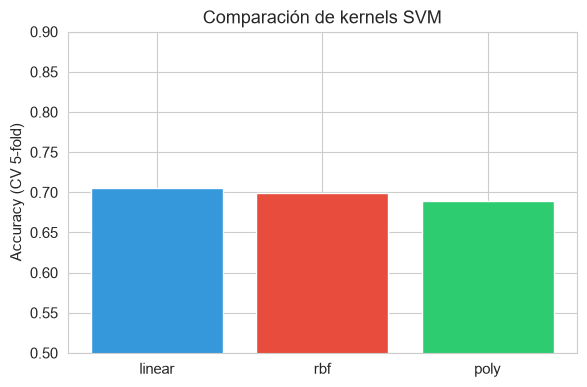

In [25]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=k, C=1.0, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.5, 0.9)
plt.tight_layout()
plt.show()

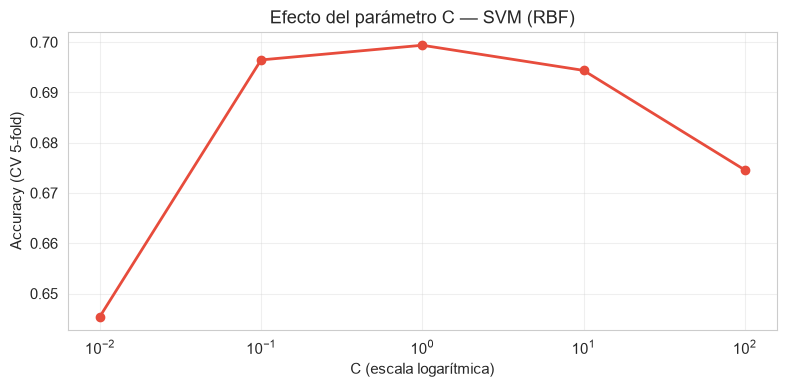


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [26]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

In [27]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1"].mean():.4f} ± {cv_knn["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall"].mean():.4f} ± {cv_knn["test_recall"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Accuracy:  0.6648 ± 0.0096
  F1-Score:  0.4691 ± 0.0135
  Recall:    0.4178 ± 0.0159


=== KNN (K=5) ===
  Accuracy: 0.6583
  Precision: 0.5223
  Recall: 0.4141
  F1-Score: 0.4619


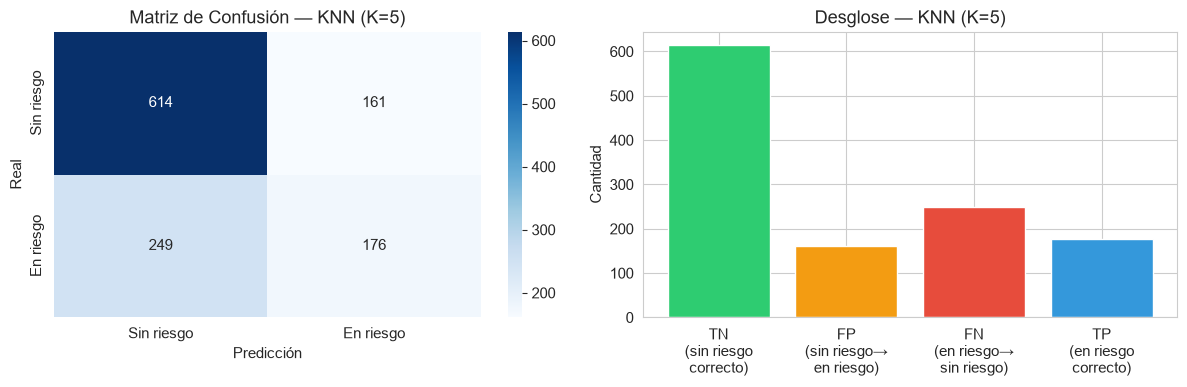


  FN (en riesgo no detectado): 249
  FP (sin riesgo marcado como en riesgo): 161

Reporte completo:
              precision    recall  f1-score   support

  sin riesgo       0.71      0.79      0.75       775
   en riesgo       0.52      0.41      0.46       425

    accuracy                           0.66      1200
   macro avg       0.62      0.60      0.61      1200
weighted avg       0.64      0.66      0.65      1200



In [28]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

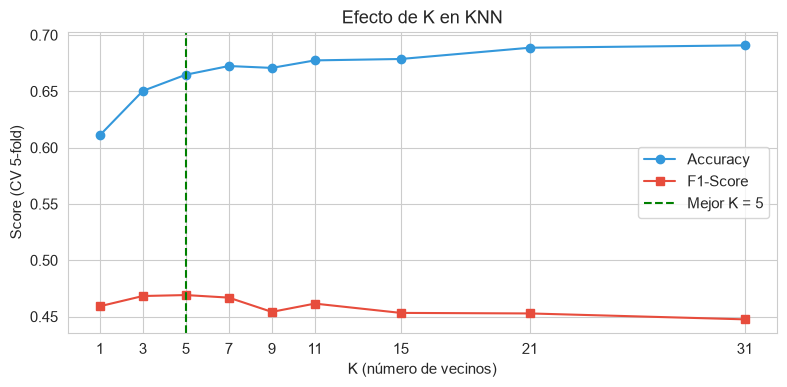

Mejor K por F1: 5
K empírico (√4800): 69


In [29]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring=['accuracy', 'f1'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [30]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.4691
  Distancia manhattan           : F1 = 0.4707
  Distancia minkowski (p=3)     : F1 = 0.4685


---
## 9. Comparación final de modelos

In [31]:
# 9.1  Tabla resumen de métricas
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn
}

all_metrics = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None
    
    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.7150,0.6456,0.4329,0.5183,0.7510
Árbol de Decisión,0.7042,0.6241,0.4141,0.4979,0.7338
SVM (RBF),0.7000,0.6757,0.2941,0.4098,0.7146
KNN (K=5),0.6583,0.5223,0.4141,0.4619,0.6377


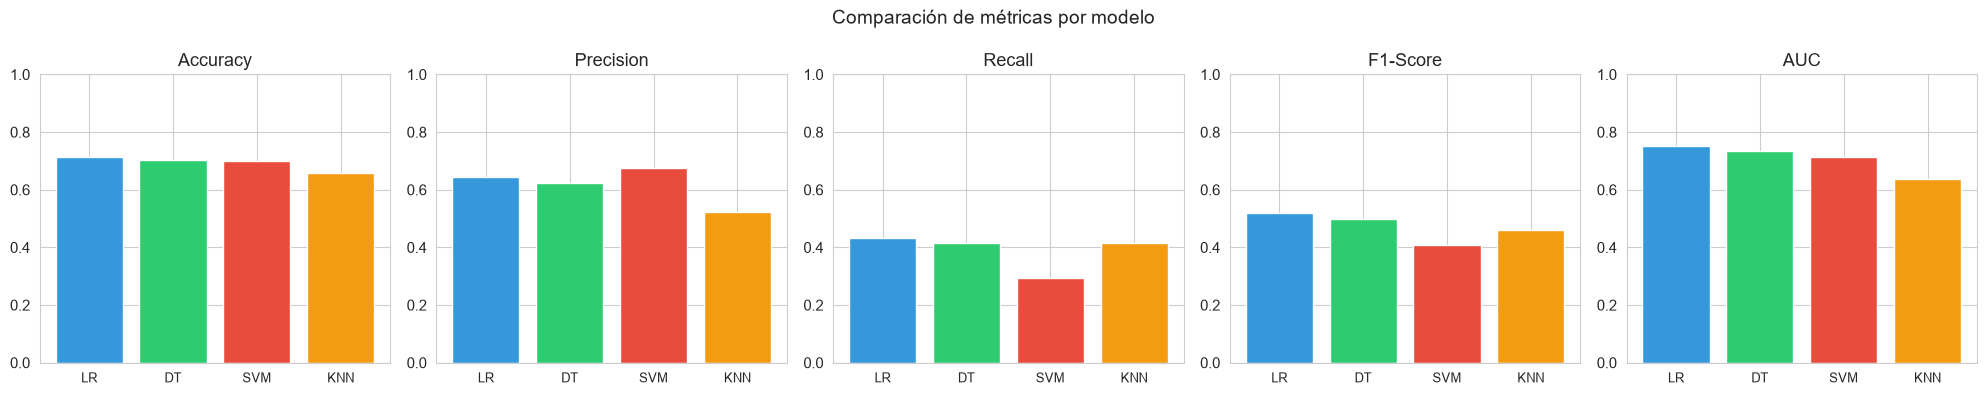

In [32]:
# 9.2  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]
    axes[i].bar(range(len(values)), values, color=colors_models)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1.0)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN'], fontsize=9)

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

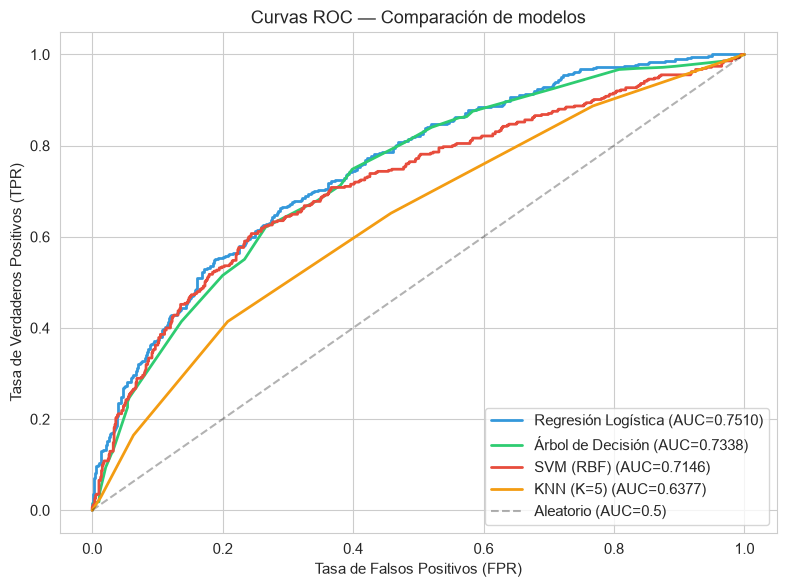

In [33]:
# 9.3  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [34]:
# 9.4  Matriz de selección
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
selection_matrix

=== Matriz de Selección de Modelos ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★★☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Asume linealidad en log-odds | Clasificación binaria con necesidad de interpretabilidad |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta, márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, maldición de la dimensionalidad | Datasets pequeños-medianos con features normalizadas |

**Criterio de selección final:** En este problema (detectar estudiantes en riesgo), **Recall** de la clase "en riesgo" es la métrica prioritaria (minimizar falsos negativos, es decir, estudiantes en riesgo no detectados). El modelo con mejor Recall en test es el candidato preferido.

---
## 11. Ejercicios propuestos

### Ejercicio 1 — Optimización con GridSearchCV
Para cada modelo, búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`. Parámetros:
- **LogisticRegression:** C=[0.01, 0.1, 1, 10, 100]
- **DecisionTree:** max_depth=[3,5,7,10,None], min_samples_leaf=[1,5,10]
- **SVM:** C=[0.1,1,10], gamma=[0.001,0.01,0.1]
- **KNN:** n_neighbors=[3,5,9,15,21], weights=['uniform','distance']

Se comparan los mejores modelos optimizados.

In [35]:
# Ejercicio 1 — GridSearchCV para cada modelo
grids = {
    'Regresión Logística': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
        {'clf__C': [0.01, 0.1, 1, 10, 100]}
    ),
    'Árbol de Decisión': (
        Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
        {'clf__max_depth': [3, 5, 7, 10, None],
         'clf__min_samples_leaf': [1, 5, 10]}
    ),
    'SVM (RBF)': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', SVC(kernel='rbf', random_state=42))]),
        {'clf__C': [0.1, 1, 10],
         'clf__gamma': [0.001, 0.01, 0.1]}
    ),
    'KNN': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', KNeighborsClassifier())]),
        {'clf__n_neighbors': [3, 5, 9, 15, 21],
         'clf__weights': ['uniform', 'distance']}
    )
}

best_models = {}
for name, (pipe, param_grid) in grids.items():
    gs = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    best_models[name] = gs
    params = {k.replace('clf__', ''): v for k, v in gs.best_params_.items()}
    print(f'{name:20s} F1 CV = {gs.best_score_:.4f}  |  {params}')

Regresión Logística  F1 CV = 0.4948  |  {'C': 1}
Árbol de Decisión    F1 CV = 0.4761  |  {'max_depth': 7, 'min_samples_leaf': 5}
SVM (RBF)            F1 CV = 0.4462  |  {'C': 10, 'gamma': 0.001}
KNN                  F1 CV = 0.4873  |  {'n_neighbors': 3, 'weights': 'distance'}


In [36]:
# Comparación: modelos base vs modelos optimizados (Test Set)
comp_rows = []
for name, gs in best_models.items():
    y_pred_opt = gs.predict(X_test)
    base = all_metrics[name if name != 'KNN' else 'KNN (K=5)']
    comp_rows.append({
        'Modelo': name,
        'F1 base': base['F1-Score'],
        'F1 optimizado': f1_score(y_test, y_pred_opt),
        'Recall base': base['Recall'],
        'Recall optimizado': recall_score(y_test, y_pred_opt),
        'Accuracy optimizado': accuracy_score(y_test, y_pred_opt)
    })

comparacion_grid = pd.DataFrame(comp_rows).set_index('Modelo').round(4)
print('=== Modelos base vs optimizados con GridSearchCV (Test Set) ===')
comparacion_grid

=== Modelos base vs optimizados con GridSearchCV (Test Set) ===


,F1 base,F1 optimizado,Recall base,Recall optimizado,Accuracy optimizado
Modelo,,,,,
Regresión Logística,0.5183,0.5183,0.4329,0.4329,0.7150
Árbol de Decisión,0.4979,0.5291,0.4141,0.4706,0.7033
SVM (RBF),0.4098,0.4702,0.2941,0.3529,0.7183
KNN,0.4619,0.4598,0.4141,0.4306,0.6417


### Ejercicio 2 — Manejo de desbalance con class_weight y SMOTE
Se entrenan los modelos con `class_weight='balanced'` y se compara el Recall de la clase "en riesgo" con y sin balanceo. Además, se aplica SMOTE sobre el conjunto de entrenamiento.

*Nota:* `KNeighborsClassifier` no admite el parámetro `class_weight`, por lo que ese modelo solo se evalúa sin balanceo y con SMOTE.

In [37]:
# Ejercicio 2 — Instalación de imbalanced-learn (solo si no está disponible)
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    %pip install -q imbalanced-learn
    from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print('Distribución de clases en train:')
print(f'  Original: {y_train.value_counts().to_dict()}')
print(f'  Con SMOTE: {pd.Series(y_res).value_counts().to_dict()}')

Note: you may need to restart the kernel to use updated packages.
Distribución de clases en train:
  Original: {0: 3098, 1: 1702}
  Con SMOTE: {0: 3098, 1: 3098}


In [38]:
# Recall de la clase "en riesgo": sin balanceo vs class_weight vs SMOTE
def crear_modelos(balanced=False):
    cw = 'balanced' if balanced else None
    modelos = {
        'Regresión Logística': Pipeline([('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, class_weight=cw, random_state=42))]),
        'Árbol de Decisión': Pipeline([('clf', DecisionTreeClassifier(
            max_depth=5, min_samples_split=10, min_samples_leaf=5,
            class_weight=cw, random_state=42))]),
        'SVM (RBF)': Pipeline([('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', C=1.0, class_weight=cw, random_state=42))]),
        'KNN (K=5)': Pipeline([('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier(n_neighbors=5))])
    }
    return modelos

filas = []
sin_balanceo = crear_modelos(balanced=False)
con_pesos = crear_modelos(balanced=True)
con_smote = crear_modelos(balanced=False)

for name in sin_balanceo:
    # 1) Sin balanceo
    sin_balanceo[name].fit(X_train, y_train)
    pred_sin = sin_balanceo[name].predict(X_test)

    # 2) class_weight='balanced' (KNN no lo soporta)
    if name != 'KNN (K=5)':
        con_pesos[name].fit(X_train, y_train)
        pred_cw = con_pesos[name].predict(X_test)
        recall_cw, f1_cw = recall_score(y_test, pred_cw), f1_score(y_test, pred_cw)
    else:
        recall_cw, f1_cw = np.nan, np.nan

    # 3) SMOTE
    con_smote[name].fit(X_res, y_res)
    pred_sm = con_smote[name].predict(X_test)

    filas.append({
        'Modelo': name,
        'Recall sin balanceo': recall_score(y_test, pred_sin),
        'Recall class_weight': recall_cw,
        'Recall SMOTE': recall_score(y_test, pred_sm),
        'F1 sin balanceo': f1_score(y_test, pred_sin),
        'F1 class_weight': f1_cw,
        'F1 SMOTE': f1_score(y_test, pred_sm)
    })

comparacion_balance = pd.DataFrame(filas).set_index('Modelo').round(4)
print('=== Clase "en riesgo": efecto del balanceo (Test Set) ===')
comparacion_balance

=== Clase "en riesgo": efecto del balanceo (Test Set) ===


,Recall sin balanceo,Recall class_weight,Recall SMOTE,F1 sin balanceo,F1 class_weight,F1 SMOTE
Modelo,,,,,,
Regresión Logística,0.4329,0.6988,0.6941,0.5183,0.6055,0.6014
Árbol de Decisión,0.4141,0.6024,0.7506,0.4979,0.5577,0.5853
SVM (RBF),0.2941,0.6824,0.6165,0.4098,0.5930,0.5829
KNN (K=5),0.4141,NaN,0.5624,0.4619,NaN,0.5151


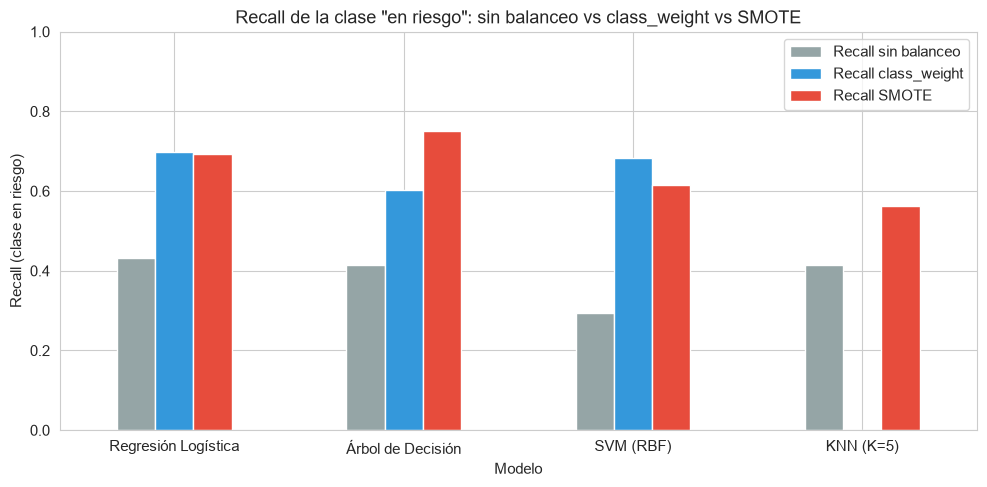

In [39]:
# Gráfico comparativo del Recall
fig, ax = plt.subplots(figsize=(10, 5))
comparacion_balance[['Recall sin balanceo', 'Recall class_weight', 'Recall SMOTE']].plot(
    kind='bar', ax=ax, color=['#95a5a6', '#3498db', '#e74c3c'])
ax.set_ylabel('Recall (clase en riesgo)')
ax.set_title('Recall de la clase "en riesgo": sin balanceo vs class_weight vs SMOTE')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Ejercicio 3 — Dataset propio
Se aplicó el ciclo completo (secciones 2 a 10) al dataset **AI and Social Media Impact** con los 4 modelos, curvas ROC y matriz de selección. A continuación se agrega un modelo adicional (**Random Forest**), se actualiza la comparación y se justifica el mejor modelo.

Random Forest — Cross-Validation (5-fold)
  Accuracy:  0.7050 ± 0.0156
  F1-Score:  0.4609 ± 0.0288
  Recall:    0.3561 ± 0.0287
=== Random Forest ===
  Accuracy: 0.7167
  Precision: 0.6889
  Recall: 0.3647
  F1-Score: 0.4769


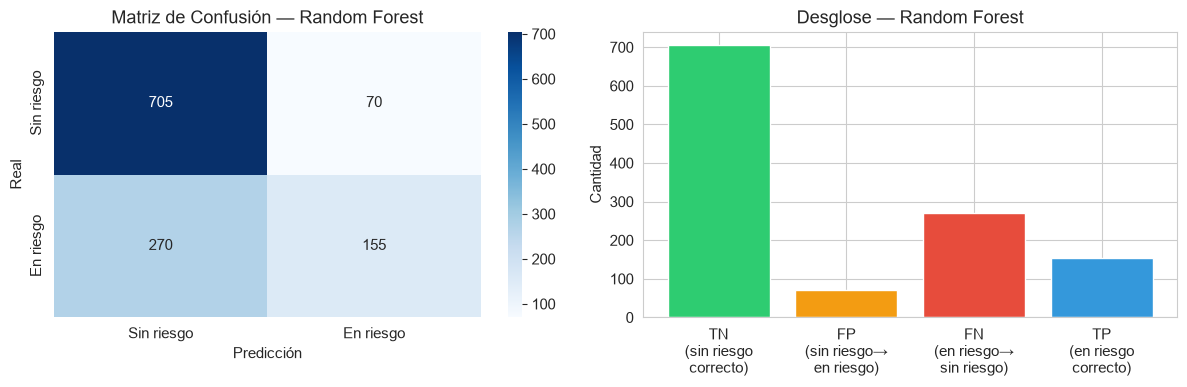


  FN (en riesgo no detectado): 270
  FP (sin riesgo marcado como en riesgo): 70

Reporte completo:
              precision    recall  f1-score   support

  sin riesgo       0.72      0.91      0.81       775
   en riesgo       0.69      0.36      0.48       425

    accuracy                           0.72      1200
   macro avg       0.71      0.64      0.64      1200
weighted avg       0.71      0.72      0.69      1200



In [40]:
# Ejercicio 3 — Modelo adicional: Random Forest
pipe_rf = Pipeline([
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=7,
                                   min_samples_leaf=5, random_state=42))
])

cv_rf = cross_validate(pipe_rf, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Random Forest — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_rf["test_accuracy"].mean():.4f} ± {cv_rf["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_rf["test_f1"].mean():.4f} ± {cv_rf["test_f1"].std():.4f}')
print(f'  Recall:    {cv_rf["test_recall"].mean():.4f} ± {cv_rf["test_recall"].std():.4f}')

pipe_rf.fit(X_train, y_train)
metrics_rf = eval_classifier(pipe_rf, X_train, y_train, X_test, y_test, 'Random Forest')

=== Tabla comparativa de métricas — 5 modelos (Test Set) ===
                     Accuracy  Precision  Recall  F1-Score     AUC
Regresión Logística    0.7150     0.6456  0.4329    0.5183  0.7510
Árbol de Decisión      0.7042     0.6241  0.4141    0.4979  0.7338
SVM (RBF)              0.7000     0.6757  0.2941    0.4098  0.7146
KNN (K=5)              0.6583     0.5223  0.4141    0.4619  0.6377
Random Forest          0.7167     0.6889  0.3647    0.4769  0.7445


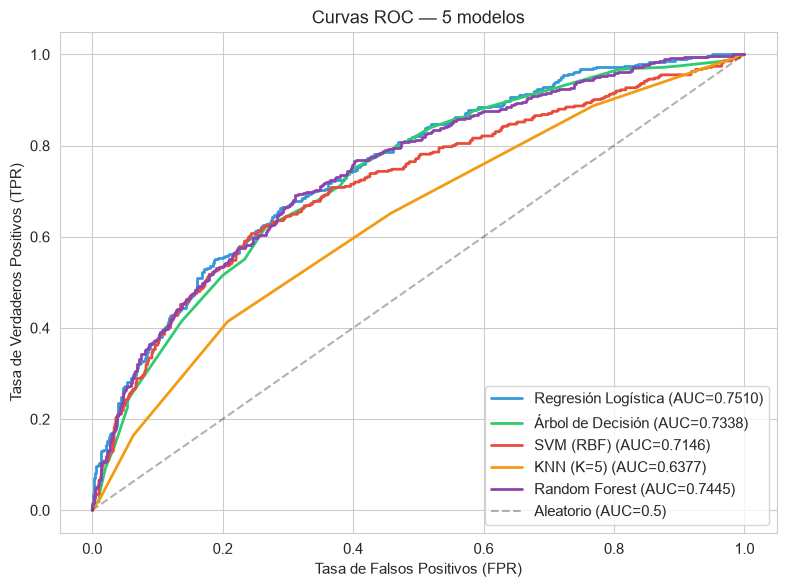

In [41]:
# Comparación de los 5 modelos: métricas y curvas ROC
all_models_5 = dict(all_models)
all_models_5['Random Forest'] = pipe_rf

all_metrics_5 = {}
for name, model in all_models_5.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    all_metrics_5[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': auc(fpr, tpr)
    }

metrics_df_5 = pd.DataFrame(all_metrics_5).T.round(4)
print('=== Tabla comparativa de métricas — 5 modelos (Test Set) ===')
print(metrics_df_5)

fig, ax = plt.subplots(figsize=(8, 6))
colors_5 = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#8e44ad']
for (name, model), color in zip(all_models_5.items(), colors_5):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={auc(fpr, tpr):.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — 5 modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [42]:
# Matriz de selección (5 modelos) y justificación del mejor modelo
selection_matrix_5 = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN', 'Random Forest'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆', '★★★★★'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★', '★★★☆☆'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆', '★★★★☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆', '★★★★★']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos (5 modelos) ===')
print(selection_matrix_5)

# Justificación: criterio prioritario = Recall de la clase "en riesgo"
mejor = metrics_df_5['Recall'].idxmax()
m = metrics_df_5.loc[mejor]
print(f'\nMejor modelo según el criterio (mayor Recall en "en riesgo"): {mejor}')
print(f'  Recall = {m["Recall"]:.4f}  |  Precision = {m["Precision"]:.4f}  |  F1 = {m["F1-Score"]:.4f}  |  AUC = {m["AUC"]:.4f}')
print(f'\nMejor AUC (capacidad de separación general): {metrics_df_5["AUC"].idxmax()} ({metrics_df_5["AUC"].max():.4f})')
print(f'Mejor F1 (equilibrio Recall/Precision):       {metrics_df_5["F1-Score"].idxmax()} ({metrics_df_5["F1-Score"].max():.4f})')

=== Matriz de Selección de Modelos (5 modelos) ===
                  Precisión predictiva Velocidad (train+pred)  \
Modelo                                                          
Reg. Logística                   ★★★★☆                  ★★★★★   
Árbol de Decisión                ★★★☆☆                  ★★★★☆   
SVM (RBF)                        ★★★★★                  ★★★☆☆   
KNN                              ★★★★☆                  ★★★★★   
Random Forest                    ★★★★★                  ★★★☆☆   

                  Interpretabilidad Escalabilidad Robustez a outliers  
Modelo                                                                 
Reg. Logística                ★★★★☆         ★★★★★               ★★★☆☆  
Árbol de Decisión             ★★★★★         ★★★★☆               ★★★★☆  
SVM (RBF)                     ★★☆☆☆         ★★☆☆☆               ★★★★☆  
KNN                           ★★★☆☆         ★★☆☆☆               ★★☆☆☆  
Random Forest                 ★★★☆☆         ★★★★☆            

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*